In [53]:
# Step 1: Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [25]:
# Step 2: Load the dataset
df = pd.read_csv('bank-full.csv', sep=';')  # Local path if you're running it
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


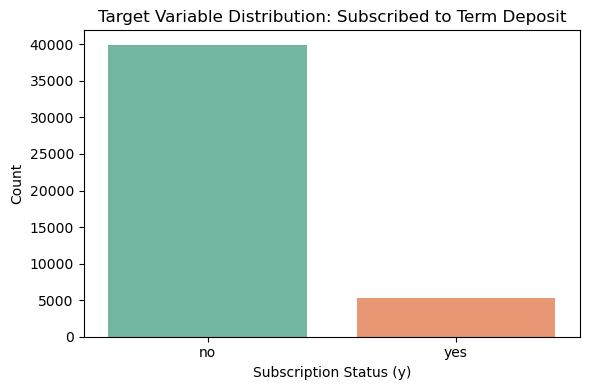

In [23]:
# Step 3: Plot histogram of the target variable 
plt.figure(figsize=(6, 4))
sns.countplot(x='y', hue='y', data=df, palette='Set2', legend=False)
plt.title('Target Variable Distribution: Subscribed to Term Deposit')
plt.xlabel('Subscription Status (y)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [27]:
# Step 4: Explore class distribution
print("Samples:", len(df))
print("Class distribution:\n", df['y'].value_counts())

Samples: 45211
Class distribution:
 y
no     39922
yes     5289
Name: count, dtype: int64


In [37]:
# Step 5: Encode categorical variables
df_encoded = df.copy()
label_encoders = {}
for column in df_encoded.select_dtypes(include='object'):
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    label_encoders[column] = le

# Step 6: Feature-target split
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Step 7: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Step 8: Scale numerical features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 9: Train a Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

Training samples: 36168
Testing samples: 9043


DecisionTreeClassifier(random_state=42)

In [47]:
# Step 10: Make predictions and evaluate
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print("Accuracy  :", round(accuracy, 2))
print("Precision :", round(precision, 2))
print("Recall    :", round(recall, 2))
print("F1 Score  :", round(f1, 2))


Model Evaluation Metrics:
Accuracy  : 0.87
Precision : 0.48
Recall    : 0.48
F1 Score  : 0.48


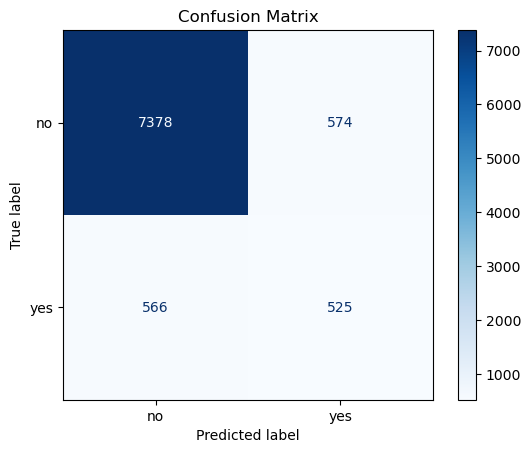

In [33]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoders['y'].classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

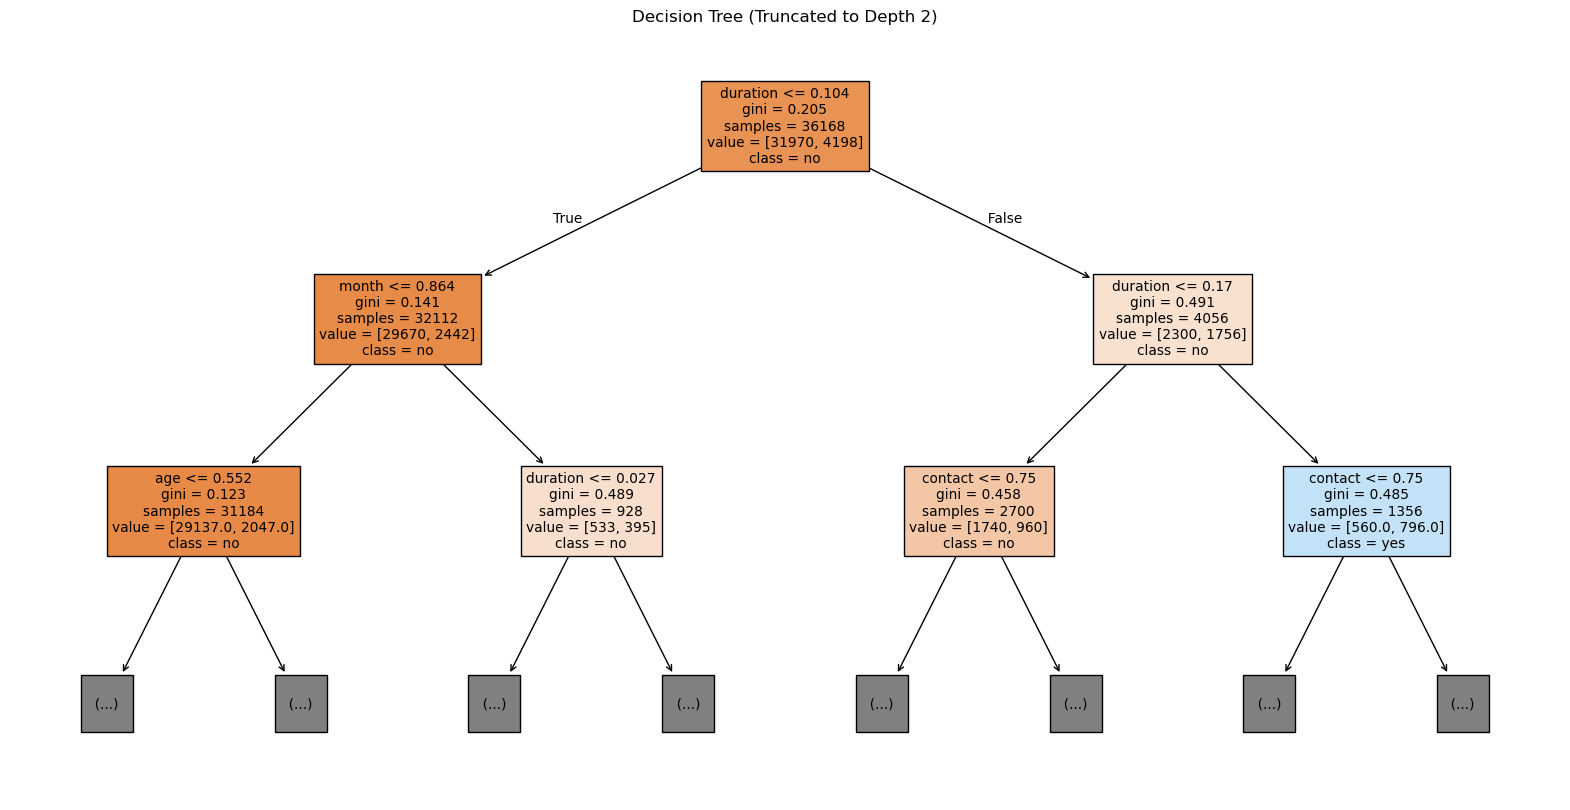

In [35]:
# Plot Decision Tree (only to visualize)
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=label_encoders['y'].classes_, filled=True, max_depth=2)
plt.title("Decision Tree (Truncated to Depth 2)")
plt.show()

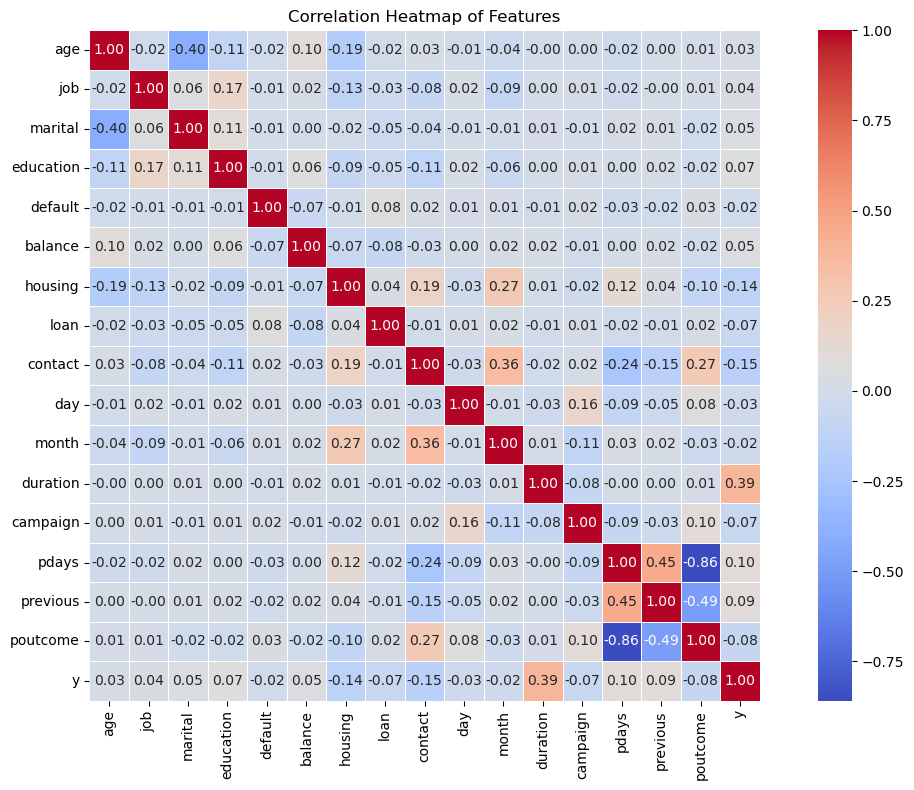

In [15]:
#Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=True, fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.show()

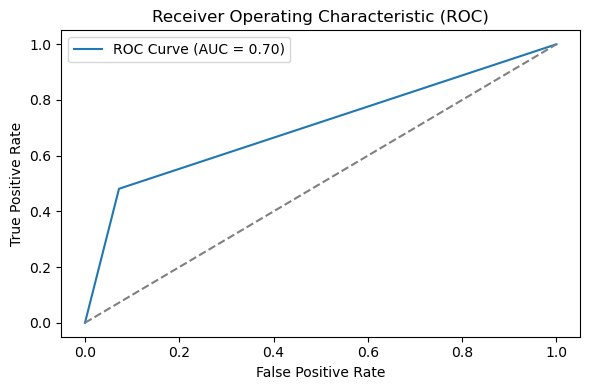

In [55]:
# ROC curve

# Predict probabilities instead of labels
y_scores = model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend()
plt.tight_layout()
plt.show()
